# 3 — The penalty weight is not a parameter

*Series: **Bayesian fluorescence decays**, notebook 3 of 8. Builds §5 of
`THEORY.md`.*

**What this notebook establishes.** That the roughness weight $\lambda$ cannot
be fitted alongside everything else — the joint mode runs away to a
distribution with no populations in it — and what to do instead: integrate it
out on a grid and mix the results by their evidence.

---

## The joint posterior

$$
\pi(\theta,\lambda\mid y)\;\propto\;
\underbrace{L(y\mid\theta)}_{\text{Poisson}}\;
\underbrace{\lambda^{r/2}\exp\!\big(-\tfrac{\lambda}{2}\|\mathbf D_m c\|^2\big)}_{\pi(c\mid\lambda)}\;
\pi(\theta_{\setminus c})\,\pi(\lambda),
\qquad r=\operatorname{rank}(\mathbf D_m\Phi).
$$

Look at the factor $\lambda^{r/2}$. It is the **normalising constant** of the
roughness prior, and it grows with $\lambda$. So if the fit is allowed to move
$\lambda$ as if it were a coordinate, it can raise the posterior simply by
making $c$ smooth and $\lambda$ large — the smoother the distribution, the
more the normaliser pays. There is no data term to stop it, because a smoother
distribution costs very little likelihood along the directions notebook 2
showed are invisible.

This is the classical failure of joint maximisation over a variance component.
It is not subtle here, and the next cells show it.

In [1]:
import sys, time, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '.')
import numpy as np, matplotlib.pyplot as plt
import bd
bd.keep_inline()          # the prototype's modules switch matplotlib to a file backend on import

S = bd.default_settings(); S['threads'] = 4
model = bd.build_model(S)
L, rel = model['L'], model['rel']
p_true = bd.gaussian_truth(model, [0.85, 1.15], [0.55, 0.45], 0.06)
y, lam_true, vals = bd.simulate_ensemble(model, S, p_true, x_d0=0.2, photons=3e5, seed=3)
print('the same data as notebook 2: two populations at R/R0 0.85 and 1.15, 20 % donor only')

  maps loaded from /Users/tpeulen/dev/ucfret/investigation/pinn_pR_anisotropy/ckpt/homog/s87_env_128_v2.pt
the same data as notebook 2: two populations at R/R0 0.85 and 1.15, 20 % donor only


## A Laplace approximation at each of five weights

For a fixed $\lambda$ the posterior over everything else is unimodal and
well behaved, and a Laplace approximation is exactly what one wants:

$$
\hat\theta_\lambda=\arg\max_\theta \log\pi(\theta,\lambda\mid y),
\qquad
\mathbf H_\lambda = -\nabla^2\log\pi\big|_{\hat\theta_\lambda},
\qquad
\pi(\theta\mid y,\lambda)\approx\mathcal N(\hat\theta_\lambda,\mathbf H_\lambda^{-1}).
$$

The mode is found by Fisher scoring with Levenberg–Marquardt damping: the
expected information $\mathbf J^\top\!\operatorname{diag}(1/\lambda)\mathbf J$
is positive semi-definite by construction, which an observed Hessian on the
way to a mode is not. This takes about a minute per node.

In [2]:
t0 = time.time()
grid = [2.0, 1.0, 0.0, -1.0, -2.0]
nodes = [bd.fit_at_lambda(model, y, lg) for lg in grid]
print(f'{len(grid)} nodes in {time.time()-t0:.0f} s; figure backend {bd.assert_inline()}\n')
print(f"{'log10 lambda':>13}{'D/dof':>9}{'log evidence':>15}{'iterations':>12}")
for n in nodes:
    print(f"{n['log10_lam']:>13.1f}{n['dev']/n['dof']:>9.4f}{n['evidence']:>15.2f}{n['n_iter']:>12d}")

5 nodes in 232 s; figure backend inline

 log10 lambda    D/dof   log evidence  iterations
          2.0   1.0715    13915304.72          37
          1.0   1.0674    13915308.96          37
          0.0   1.0667    13915307.50          45
         -1.0   1.0660    13915302.93          46
         -2.0   1.0652    13915297.36          61


## What the weight does to the answer

The five distributions below are the same data seen through five priors. The
deviance barely moves across them — the data cannot tell these apart — while
the distribution goes from spiky to a single hump. **The likelihood is not
what chooses $\lambda$, and it cannot be.**

deviance per dof across four decades of lambda: 1.0652 to 1.0715, a spread of 0.6 %


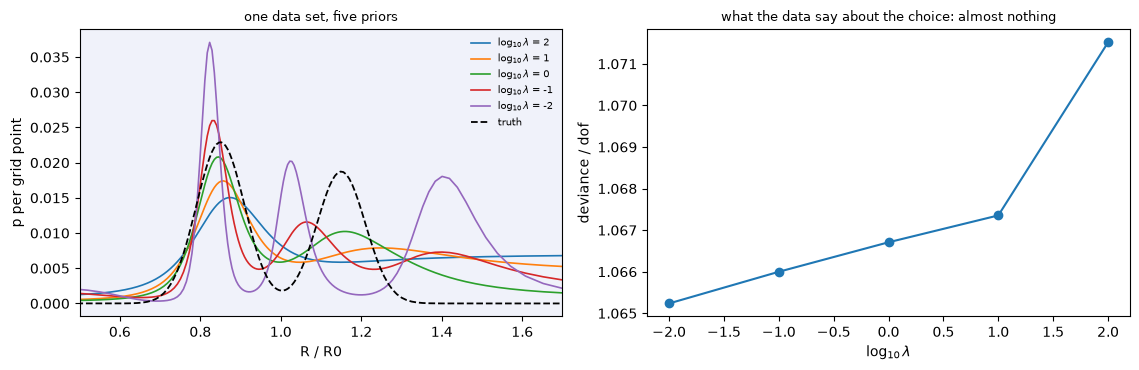

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8))
for n, c in zip(nodes, ('C0', 'C1', 'C2', 'C3', 'C4')):
    ax[0].plot(rel, n['p'], c, lw=1.2, label=f"$\\log_{{10}}\\lambda$ = {n['log10_lam']:.0f}")
ax[0].plot(rel, p_true, 'k--', lw=1.3, label='truth')
ax[0].set_xlabel('R / R0'); ax[0].set_ylabel('p per grid point'); ax[0].set_xlim(0.5, 1.7)
L.shade_window(ax[0], 0.01, label=False); ax[0].legend(fontsize=7, frameon=False)
ax[0].set_title('one data set, five priors', fontsize=9)
d = np.array([n['dev'] / n['dof'] for n in nodes])
ax[1].plot(grid, d, 'C0o-')
ax[1].set_xlabel('$\\log_{10}\\lambda$'); ax[1].set_ylabel('deviance / dof')
ax[1].set_title('what the data say about the choice: almost nothing', fontsize=9)
fig.tight_layout()
print(f'deviance per dof across four decades of lambda: {d.min():.4f} to {d.max():.4f}, '
      f'a spread of {100*(d.max()-d.min())/d.mean():.1f} %')

## The joint mode, for the record

Now let $\lambda$ be a coordinate and maximise everything at once. This is the
thing not to do, and it is worth seeing rather than being told.

joint mode in 94 s
joint mode:  log10 lambda 3.02, D/dof 1.0845
fixed node:  log10 lambda 0.00, D/dof 1.0667
  truth       mean 0.969  width 0.150  peaks 2
  fixed node  mean 0.995  width 0.197  peaks 2
  joint mode  mean 0.977  width 0.214  peaks 1


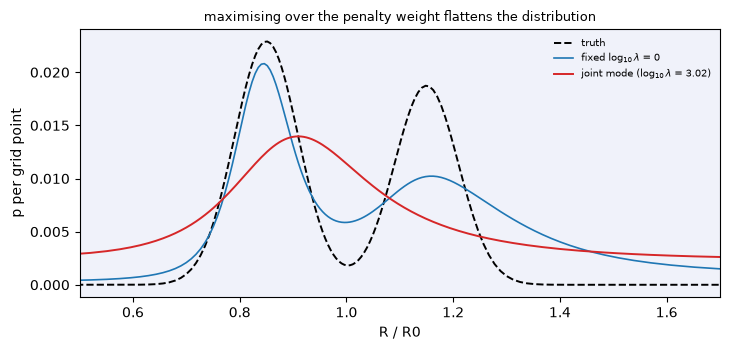

In [4]:
t0 = time.time()
jm = bd.joint_mode(model, y)
print(f'joint mode in {time.time()-t0:.0f} s')
fig, ax = plt.subplots(figsize=(7.4, 3.6))
ax.plot(rel, p_true, 'k--', lw=1.4, label='truth')
ax.plot(rel, nodes[2]['p'], 'C0', lw=1.2, label=f"fixed $\\log_{{10}}\\lambda$ = {nodes[2]['log10_lam']:.0f}")
ax.plot(rel, jm['p'], 'C3', lw=1.4, label=f"joint mode ($\\log_{{10}}\\lambda$ = {jm['log10_lam']:.2f})")
ax.set_xlabel('R / R0'); ax.set_ylabel('p per grid point'); ax.set_xlim(0.5, 1.7)
L.shade_window(ax, 0.01, label=False); ax.legend(fontsize=7, frameon=False)
ax.set_title('maximising over the penalty weight flattens the distribution', fontsize=9)
fig.tight_layout()
print(f"joint mode:  log10 lambda {jm['log10_lam']:.2f}, D/dof {jm['dev']/jm['dof']:.4f}")
print(f"fixed node:  log10 lambda {nodes[2]['log10_lam']:.2f}, D/dof {nodes[2]['dev']/nodes[2]['dof']:.4f}")
def summ(p):
    m = float((p * rel).sum()); return m, float(np.sqrt((p * (rel - m) ** 2).sum()))
for nm, p_ in (('truth', p_true), ('fixed node', nodes[2]['p']), ('joint mode', jm['p'])):
    m, s = summ(p_); print(f'  {nm:<11} mean {m:.3f}  width {s:.3f}  peaks {int((np.diff(np.sign(np.diff(p_))) < 0).sum())}')

## Integrating the weight out

The correct treatment is to average over $\lambda$ rather than to choose it.
Marginally,

$$
\pi(\lambda\mid y)\;\propto\;\pi(\lambda)\int \pi(\theta,\lambda\mid y)\,\mathrm d\theta
\;\approx\;\pi(\lambda)\,
\exp\!\Big[\log\pi(\hat\theta_\lambda,\lambda\mid y)+\tfrac d2\log 2\pi-\tfrac12\log|\mathbf H_\lambda|\Big],
$$

the Laplace approximation of the evidence at each node, and the posterior of
everything else is the **evidence-weighted mixture of the nodes' Gaussians**

$$
\pi(\theta\mid y)\approx\sum_\ell w_\ell\,\mathcal N(\hat\theta_\ell,\mathbf H_\ell^{-1}),
\qquad
w_\ell\propto Z(\lambda_\ell)\pi(\lambda_\ell).
$$

This is INLA's treatment of a hyperparameter (Rue, Martino & Chopin 2009), and
marginal-likelihood smoothing-parameter selection (Wood 2011) with the
selection replaced by an average. **There is no sampler**: the weights are
evidences and the components are Gaussians.

Two things the weights are not. They are not the deviance — a node that fits
marginally better can carry less evidence, because the evidence pays for the
volume the parameters occupy. And they are not a delta function — when the
data do not distinguish two decades of $\lambda$, the weights say so, and the
resulting band is wider than any single node's.

weights: +2: 0.012  +1: 0.801  +0: 0.186  -1: 0.002  -2: 0.000
evidence maximum at log10 lambda 1; the deviance is lowest at -2


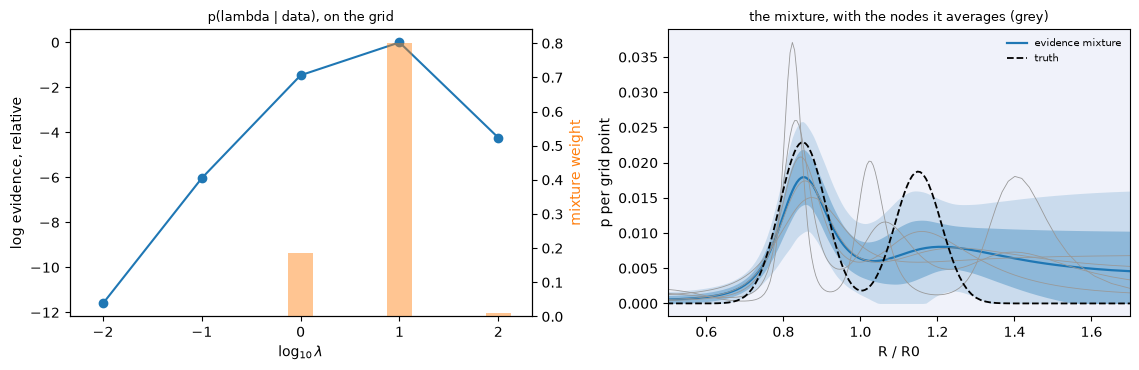

In [5]:
post = bd.mix_nodes(nodes)
ev = np.array([n['evidence'] for n in nodes]); w = post['weights']
fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8))
ax[0].plot(grid, ev - ev.max(), 'C0o-', label='log evidence')
ax2 = ax[0].twinx(); ax2.bar(grid, w, width=0.25, color='C1', alpha=0.45)
ax2.set_ylabel('mixture weight', color='C1')
ax[0].set_xlabel('$\\log_{10}\\lambda$'); ax[0].set_ylabel('log evidence, relative')
ax[0].set_title('p(lambda | data), on the grid', fontsize=9)
m, lo1, hi1, lo2, hi2 = L.delta_bands(None, post, rel, space='linear')
ax[1].fill_between(rel, lo2, hi2, color='C0', alpha=0.18, lw=0)
ax[1].fill_between(rel, lo1, hi1, color='C0', alpha=0.35, lw=0)
ax[1].plot(rel, m, 'C0', lw=1.6, label='evidence mixture')
for n, c in zip(nodes, ('0.6',) * 5):
    ax[1].plot(rel, n['p'], c, lw=0.6)
ax[1].plot(rel, p_true, 'k--', lw=1.3, label='truth')
ax[1].set_xlabel('R / R0'); ax[1].set_ylabel('p per grid point'); ax[1].set_xlim(0.5, 1.7)
L.shade_window(ax[1], 0.01, label=False); ax[1].legend(fontsize=7, frameon=False)
ax[1].set_title('the mixture, with the nodes it averages (grey)', fontsize=9)
fig.tight_layout()
print('weights: ' + '  '.join(f'{g:+.0f}: {wi:.3f}' for g, wi in zip(grid, w)))
print(f'evidence maximum at log10 lambda {post["best_lam"]:.0f}; '
      f'the deviance is lowest at {grid[int(np.argmin([n["dev"]/n["dof"] for n in nodes]))]:+.0f}')

## What was tried and rejected on the way

Three choices in the prior were argued about at length in this project, and
each was settled by measurement rather than taste. They are recorded here so
that the final model does not look arbitrary.

**The space of the penalty.** Penalising $\log p$, $\sqrt p$ or $p$ itself are
different priors. Only the first is scale free, so only the first charges the
same for a population of a given relative width wherever it sits. $\sqrt p$
was prototyped and withdrawn.

**The order of the difference.** The unpenalised functions — the null space —
are what infinite smoothing still allows, so the order *is* the null
hypothesis. Order 2 leaves $\log p$ linear, that is $p(r)\propto e^{\beta r}$;
order 3 leaves it quadratic, that is, **one Gaussian population free at every
$\lambda$**. The next cell fits a single-population truth under both and shows
the difference at the edge of the grid, which is where the null hypothesis
shows through. Order 3 gives visibly narrower bands and the same bias, and it
is **not** the default: the calibration rule declined it, and a narrower band
that is not better centred is a worse interval, not a better one.

**The band's space.** Reporting the band as a lognormal in $\log p$ is
positive by construction and useless: where $p$ is empty the Laplace standard
deviation of $\log p$ is enormous and the upper edge runs to absurd values.
The band is therefore taken in $p$ and clipped at zero. Notebook 4 shows both.

order 2: two nodes in 64 s, D/dof 1.0315 and 1.0312


order 3: two nodes in 74 s, D/dof 1.0314 and 1.0312
order 2: mass above R/R0 1.6 -- truth 0.0000, posterior 0.0004
order 3: mass above R/R0 1.6 -- truth 0.0000, posterior 0.0001


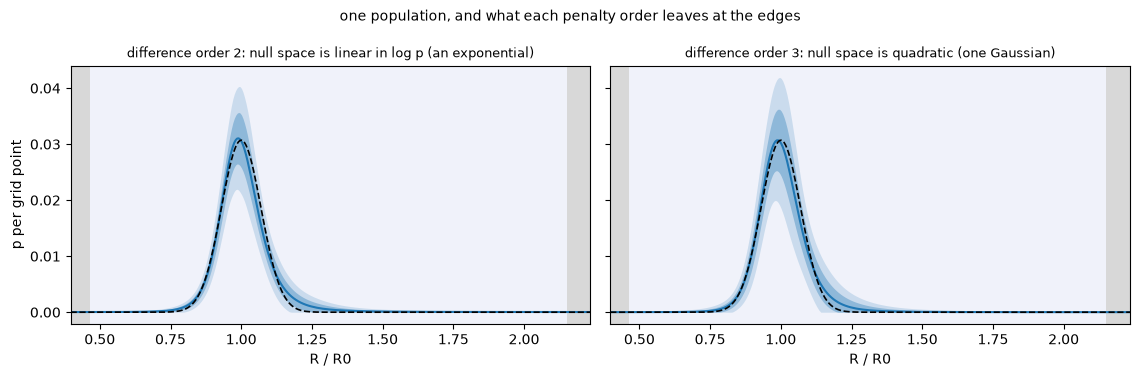

In [6]:
p_one = bd.gaussian_truth(model, [1.0], [1.0], 0.07)
y1, _, _ = bd.simulate_ensemble(model, S, p_one, x_d0=0.2, photons=3e5, seed=11)
res = {}
keep = L.PEN_ORDER
try:
    for m_ in (2, 3):
        L.PEN_ORDER = m_
        t0 = time.time()
        res[m_] = [bd.fit_at_lambda(model, y1, lg) for lg in (1.0, -1.0)]
        print(f'order {m_}: two nodes in {time.time()-t0:.0f} s, '
              f"D/dof {res[m_][0]['dev']/res[m_][0]['dof']:.4f} and {res[m_][1]['dev']/res[m_][1]['dof']:.4f}")
finally:
    L.PEN_ORDER = keep

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8), sharey=True)
for i, m_ in enumerate((2, 3)):
    pm = bd.mix_nodes(res[m_])
    mm, lo1, hi1, lo2, hi2 = L.delta_bands(None, pm, rel, space='linear')
    ax[i].fill_between(rel, lo2, hi2, color='C0', alpha=0.18, lw=0)
    ax[i].fill_between(rel, lo1, hi1, color='C0', alpha=0.35, lw=0)
    ax[i].plot(rel, mm, 'C0', lw=1.5)
    ax[i].plot(rel, p_one, 'k--', lw=1.2)
    ax[i].set_xlabel('R / R0'); ax[i].set_xlim(rel[0], rel[-1])
    L.shade_window(ax[i], 0.01, label=False)
    ax[i].set_title(f'difference order {m_}: null space is '
                    + ('linear in log p (an exponential)' if m_ == 2 else 'quadratic (one Gaussian)'), fontsize=9)
ax[0].set_ylabel('p per grid point')
fig.suptitle('one population, and what each penalty order leaves at the edges', fontsize=10)
fig.tight_layout()
edge = rel > 1.6
for m_ in (2, 3):
    pm = bd.mix_nodes(res[m_])
    mm = L.delta_bands(None, pm, rel, space='linear')[0]
    print(f'order {m_}: mass above R/R0 1.6 -- truth {p_one[edge].sum():.4f}, posterior {mm[edge].sum():.4f}')

At this photon count and this truth the effect is small — the
numbers above differ by a factor of a few on a mass of $10^{-4}$ — because the
data still push the distribution down at the edge. It becomes unmissable when
the sample has no FRET population at all to anchor it:

![the shoulder](figures/20260907T090705_s88_S11null_shoulder.png)

*A sample with no FRET population, fitted under the order-2 penalty. The
shoulder at the right-hand edge of the grid is the prior's null hypothesis
showing through — an exponential in $R/R_0$ — not a numerical artefact and not
a population.*

That diagnosis cost this project a day. It was first blamed on the $\lambda$
grid, then on the nuisance parameters, and it was neither. Once named, the
remedy is a choice with a cost: order 3 removes it, and gives narrower bands
with the same bias, which the calibration rule of notebook 5 declines.

## What comes next

The posterior is now a mixture of Gaussians in a coordinate that is not the
quantity anyone wants to report. Turning it into a statement about $p(R)$ and
its summaries is notebook 4, and it has a trap of its own.

**Established here.** The joint posterior and the normaliser that makes joint
maximisation fail (THEORY §5.2), demonstrated; the Laplace approximation at
fixed $\lambda$ (§5.3); the deviance's near-indifference to $\lambda$ over four
decades; the evidence mixture and its weights (§5.3); and the penalty's order
as a statement about the null hypothesis (§4.2), with the edge shoulder it
produces.